# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [7]:
df = pd.read_csv(r"C:\Users\bianc\PycharmProjects\PythonProject\.venv\Projetos EBAC\9. Pré-Modelagem_2\CHURN_TELECON_PROCESSADO",delimiter=",")

df.head()

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,1,0,1,0,DSL,No,No,No,Month-to-month,Electronic check,29.850000,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,DSL,Yes,No,No,One year,Mailed check,56.950000,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,DSL,Yes,No,No,Month-to-month,Mailed check,53.850000,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,DSL,Yes,Yes,No,One year,Bank transfer (automatic),40.905556,1840.75,0
4,8191-XWSZG,Female,0,0,0,52,1,No,No internet service,No internet service,No internet service,One year,Mailed check,19.672115,1022.95,0


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [8]:
df.describe()

,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Pagamento_Mensal,Total_Pago,Churn
count,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000
mean,0.161576,0.492765,0.314711,32.352090,0.965434,65.511708,2290.087178,0.260048
std,0.368135,0.500048,0.464494,24.636885,0.182714,29.920953,2264.585643,0.438749
min,0.000000,0.000000,0.000000,0.000000,0.000000,15.725000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,8.000000,1.000000,39.637500,402.337500,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,71.100000,1402.900000,0.000000
75%,0.000000,1.000000,1.000000,56.000000,1.000000,90.250000,3867.162500,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,121.400000,8564.750000,1.000000


Com o describe aplicado parece haver outliers na coluna Total_Pago, mas o boxplot poderá indicar melhor.

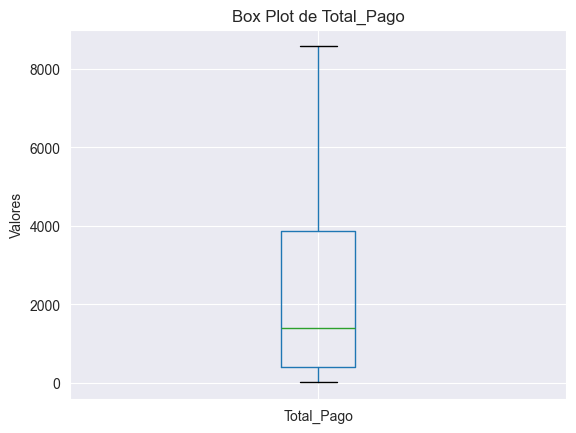

In [9]:
df.boxplot(column='Total_Pago')
plt.title('Box Plot de Total_Pago')
plt.ylabel('Valores')
plt.show()

Com o boxplot, vejo que não há outliers nessa coluna, apenas uma distribuição pouco proporcional entre si, talvez a relação com o tempo possa explicar a distribuição.

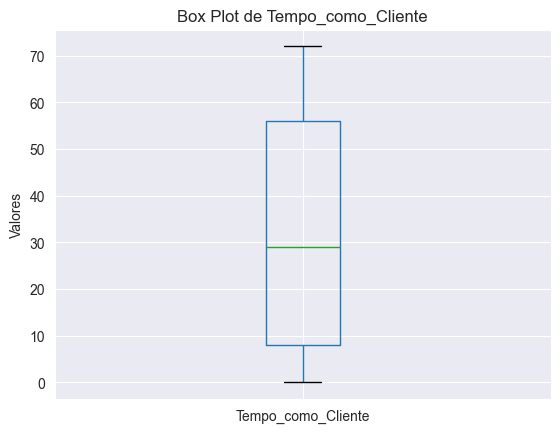

In [10]:
df.boxplot(column='Tempo_como_Cliente')
plt.title('Box Plot de Tempo_como_Cliente')
plt.ylabel('Valores')
plt.show()

A distribuição de Tempo_como_Cliente também não tem outliers, como previsto. É uma variável que é importante manter para verificar relação de tempo e fidelização dos clientes.

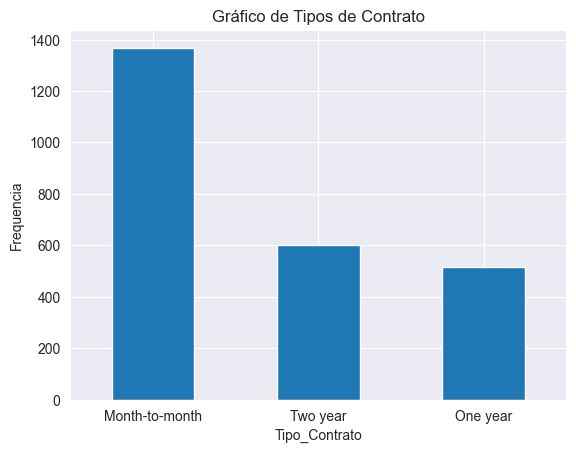

In [11]:
cont_tipo_contrato = df['Tipo_Contrato'].value_counts()
cont_tipo_contrato.plot(kind='bar')
plt.title('Gráfico de Tipos de Contrato')
plt.ylabel('Frequencia')
plt.xticks(rotation=0)
plt.show()

Conhecendo a distribuição dos tipos de contrato, podemos identificar uma dificuldade de fidelizar clientes para contratos longos, o que pode ter alguma relação com a taxa de churn, já que planos mensais são mais fáceis de cancelar do que anuais ou bianuais.

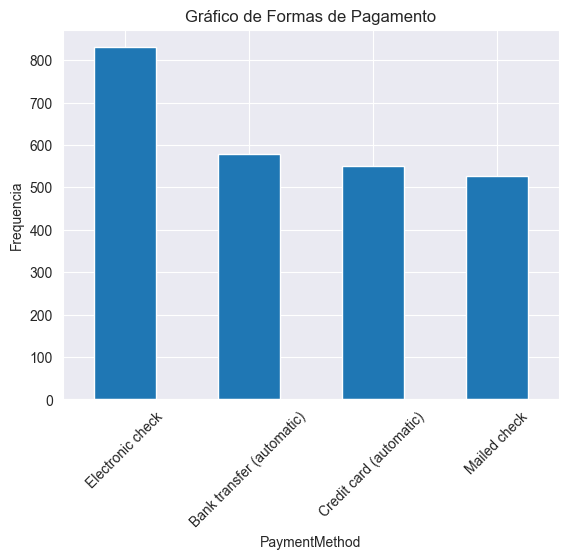

In [12]:
cont_pagamento = df['PaymentMethod'].value_counts()
cont_pagamento.plot(kind='bar')
plt.title('Gráfico de Formas de Pagamento')
plt.ylabel('Frequencia')
plt.xticks(rotation=45)
plt.show()

Pela forma de pagamento identifico que, apesar da grande quantidade de pagamento automático, muitos contratos são pagos por boleto, seja eletrônico ou físico. Isso pode ser visto pelo público como uma opção mais retrógrada apesar de ser uma escolha do cliente.

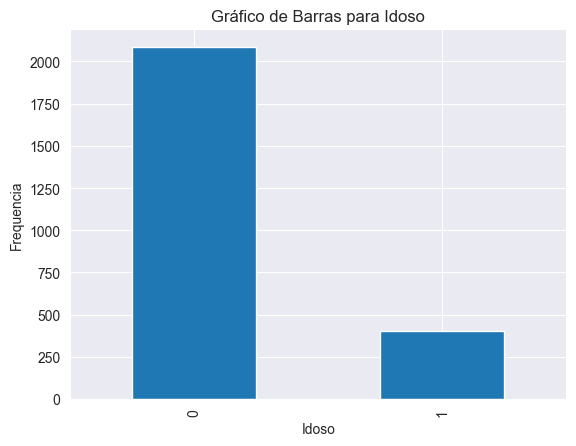

In [13]:
bool_idoso = df['Idoso'].value_counts()
bool_idoso.plot(kind='bar')
plt.title('Gráfico de Barras para Idoso')
plt.ylabel('Frequencia')
plt.show()

In [14]:
bool_idoso = df['Idoso'].value_counts()
(bool_idoso / bool_idoso.sum()) * 100

Idoso
0    83.842444
1    16.157556
Name: count, dtype: float64

Quantidade de idosos não está balanceada, mas não justifica realizar ajustes, ainda pode indicar clientes com maior tempo de uso.

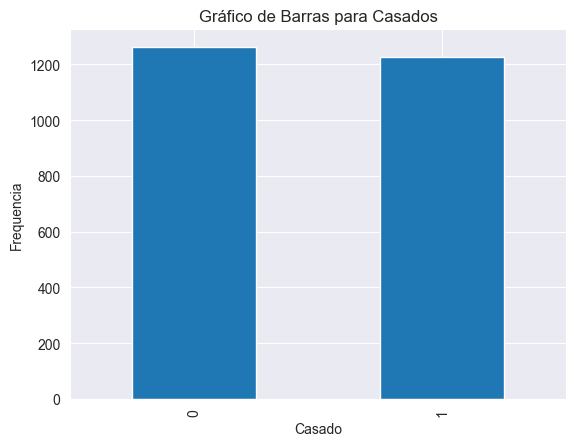

In [15]:
bool_casado = df['Casado'].value_counts()
bool_casado.plot(kind='bar')
plt.title('Gráfico de Barras para Casados')
plt.ylabel('Frequencia')
plt.show()

In [16]:
bool_casado = df['Casado'].value_counts()
(bool_casado / bool_casado.sum()) * 100

Casado
0    50.723473
1    49.276527
Name: count, dtype: float64

Variável para casados balanceada, indica uma população mais equilibrada para previsão do modelo.

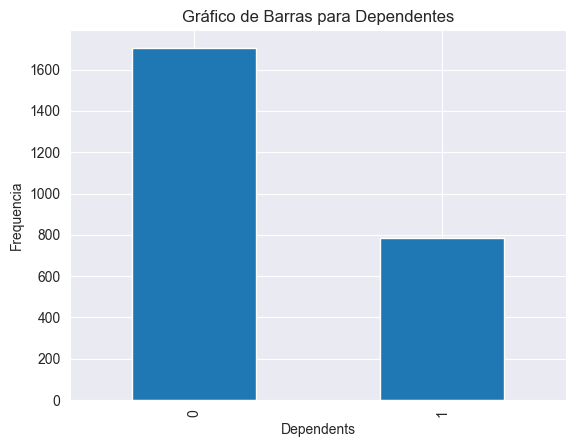

In [17]:
bool_dependente = df['Dependents'].value_counts()
bool_dependente.plot(kind='bar')
plt.title('Gráfico de Barras para Dependentes')
plt.ylabel('Frequencia')
plt.show()

In [18]:
bool_dependente = df['Dependents'].value_counts()
(bool_dependente / bool_dependente.sum()) * 100

Dependents
0    68.528939
1    31.471061
Name: count, dtype: float64

A variável para identificar dependentes não está muito balanceada, indicando mais clientes sem dependentes do que com.

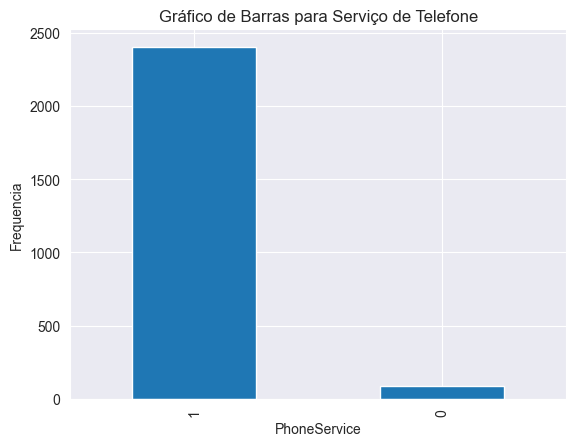

In [19]:
bool_telefone = df['PhoneService'].value_counts()
bool_telefone.plot(kind='bar')
plt.title('Gráfico de Barras para Serviço de Telefone')
plt.ylabel('Frequencia')
plt.show()

In [20]:
bool_telefone = df['PhoneService'].value_counts()
(bool_telefone / bool_telefone.sum()) * 100

PhoneService
1    96.543408
0     3.456592
Name: count, dtype: float64

A variável indicando assinatura de serviço de telefone está muito desbalanceada, o melhor nesse caso seria presumir todos as assinaturas contendo tal serviço.

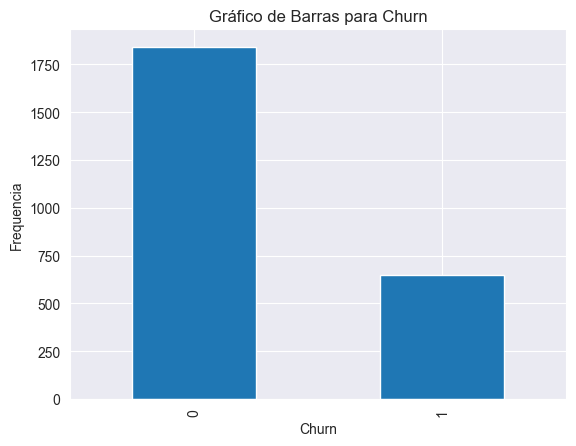

In [21]:
bool_churn = df['Churn'].value_counts()
bool_churn.plot(kind='bar')
plt.title('Gráfico de Barras para Churn')
plt.ylabel('Frequencia')
plt.show()

In [22]:
bool_churn = df['Churn'].value_counts()
(bool_churn/ bool_churn.sum()) * 100

Churn
0    73.995177
1    26.004823
Name: count, dtype: float64

Identificado também desbalanceamento na variável principal, o churn.

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


Não foi identificado outliers no dataframe.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projeto relacionadas a variável Churn?

1. O tipo de contrato impacta na recorrência do Churn. Clientes com contratos mensais são mais propensos a encerrar o contrato, uma ação para reduzir o Churn seria oferecer os contratos anuais ou bianuais com melhores preços do que os mensais, tornando essas opções mais atrativas e aumentando o período de contratação dos serviços.

In [30]:
fig = px.histogram(df, x='Churn', color='Tipo_Contrato', barmode='stack')

fig.update_layout(title='Relação entre Churn e Contrato',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Contrato')
fig.show()

2. A forma de pagamento por boleto eletrônico, enviado por e-mail, representa 58% do Churn. O pagamento direto no cartão de crédito parece uma opção menos propensa ao Churn, podendo indicar que a praticidade de não precisar se preocupar com boletos é uma prioridade para  os clientes.

In [31]:
df_grouped = df.groupby(['Churn', 'PaymentMethod']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

fig = px.bar(df_grouped, x='Churn', y='percent', color='PaymentMethod', barmode='stack',
             labels={'Churn': 'Churn', 'percent': 'Porcentagem', 'PaymentMethod': 'Forma de Pagamento'})

fig.update_layout(title='Relação entre Churn e Forma de Pagamento',
                  yaxis_title='Porcentagem',
                  legend_title='Forma de Pagamento')
fig.show()

3. Apesar da fibra ótica ser um serviço de internet mais moderno e veloz, nessa análise aparece com maior frequência de Churn. Seria interessante avaliar a qualidade do serviço para entender o que pode estar motivando os clientes a desistirem dos contratos por fibra ótica mais do que outros.

In [35]:
df_grouped = df.groupby(['Churn', 'Servico_Internet']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

fig = px.bar(df_grouped, x='Churn', y='percent', color='Servico_Internet', barmode='stack',
             labels={'Churn': 'Churn', 'percent': 'Porcentagem', 'Servico_Internet': 'Internet'})

fig.update_layout(title='Relação entre Churn e Internet',
                  yaxis_title='Porcentagem',
                  legend_title='Internet')
fig.show()

4. Ocorre mais Churn em clientes com menos de 1 ano de contrato. Os clientes mais antigos são menos propensos a encerrar as contas.

In [44]:
mediana = df.groupby('Churn')['Tempo_como_Cliente'].median().reset_index()

# Criar gráfico de barras
fig = px.bar(mediana, x='Churn', y='Tempo_como_Cliente', barmode='stack',
             title='Média Tempo como Cliente e Churn')
fig.show()

5. A maioria dos casos de Churn são de pessoas que não possuem dependentes, o que faz sentido visto que, com dependentes, é necessário que se tenha uma estabilidade maior para gerenciar as contas. Nesse caso, o oferecimento de contratos anuais ou bianuais volta a fazer sentido para não perder essa quantidade de clientes.

In [45]:
fig = px.histogram(df, x='Churn', color='Dependents', barmode='stack')

fig.update_layout(title='Relação entre Churn e Dependentes',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Dependentes')
fig.show()